# Gradient Boosting: Zero to Hero

Including XGBoost, LightGBM and CatBoost — the models that win tabular competitions.

> **Prerequisites:** [`ml_foundations_zero_to_hero.ipynb`](ml_foundations_zero_to_hero.ipynb)
> for the shared workflow, [`decision_trees_zero_to_hero.ipynb`](decision_trees_zero_to_hero.ipynb)
> for the base learner, and **[`random_forest_zero_to_hero.ipynb`](random_forest_zero_to_hero.ipynb)
> for the contrast that runs through this entire notebook.**
>
> NB-04 built an ensemble by **averaging** independent trees, which attacks **variance**.
> This one builds an ensemble by **stacking corrections**, which attacks **bias**. Almost
> every behavioural difference between the two follows from that one sentence, and Part 1
> keeps pointing back at it.

***

## Why this notebook matters most

If you only ever ship one model family on tabular data, it is this one. Gradient boosting
wins the large majority of tabular Kaggle competitions and remains, as of the most recent
benchmarks, the thing deep learning still has not displaced on structured data.

The cost is that — unlike a random forest — **it does not work well out of the box**. It has
hyperparameters that genuinely interact, it will overfit if you let it, and it is more
sensitive to noisy labels than anything else in this series. Getting the good results
requires understanding the mechanism, which is what Part 1 is for.

## Contents

| Part | What it covers |
|---|---|
| **0. Setup** | Install + imports (this one has optional extra libraries) |
| **1. Theory from zero** | Fitting your own residuals · **why it is called *gradient* boosting** · learning rate ↔ n_estimators · why base learners are shallow · early stopping · sensitivity to label noise |
| **2. The libraries** | XGBoost / LightGBM / CatBoost — why they are one to two orders of magnitude faster, and what genuinely differs between them |
| **3. Worked example** | End to end, with honest tuning |
| **4. Tough questions** | 12 questions + 3 coding challenges |
| **5. Practice datasets** | 5 datasets with briefs |
| **6. Reading the literature** | The papers behind each section |
| **Appendix** | Boosting-specific errors and a checklist |

## The one-paragraph summary

Fit a weak model. Look at what it got wrong. Fit a second model **to those errors**. Add a
small fraction of it to the first. Repeat a few hundred times. Each round nudges the ensemble
towards the training data, so boosting **reduces bias** — the opposite of bagging — which is
why its base learners are deliberately shallow and why it *can* overfit if you keep going.
The "gradient" in the name is precise rather than decorative: fitting the residual is exactly
fitting the negative gradient of squared-error loss, and swapping in a different loss just
changes what you fit each round.

***
# Part 0 - Setup

This notebook uses three optional libraries — `xgboost`, `lightgbm`, `catboost` — in Part 2.
The install cell adds them, but **everything still runs without them**: the library sections
detect what is available and skip what is not. sklearn's own
`HistGradientBoostingClassifier` is a genuinely competitive stand-in.

In [1]:
# ---------------------------------------------------------------------------
# One-time setup. Only missing packages are installed, so re-running is cheap.
# ---------------------------------------------------------------------------
import importlib.util
import subprocess
import sys

CORE = [
    ("numpy", "numpy"), ("pandas", "pandas"), ("matplotlib", "matplotlib"),
    ("scipy", "scipy"), ("sklearn", "scikit-learn"),
]
BOOSTING_LIBS = [("xgboost", "xgboost"), ("lightgbm", "lightgbm"), ("catboost", "catboost")]

for label, packages in [("core", CORE), ("boosting libraries", BOOSTING_LIBS)]:
    missing = [pip for mod, pip in packages if importlib.util.find_spec(mod) is None]
    if missing:
        print(f"{label}: installing {', '.join(missing)} ...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
            print(f"{label}: done")
        except subprocess.CalledProcessError:
            print(f"{label}: install failed - Part 2 will skip what is missing")
    else:
        print(f"{label}: all present")

core: all present
boosting libraries: installing xgboost, lightgbm, catboost ...
boosting libraries: done


In [2]:
# ---------------------------------------------------------------------------
# Every import this notebook uses.
# ---------------------------------------------------------------------------
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (
    GradientBoostingRegressor, GradientBoostingClassifier,
    HistGradientBoostingRegressor, HistGradientBoostingClassifier,
    RandomForestRegressor, RandomForestClassifier,
)
from sklearn.datasets import make_classification, make_regression, load_breast_cancer
from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_validate,
    StratifiedKFold, RandomizedSearchCV,
)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score, log_loss,
    root_mean_squared_error, mean_absolute_error, r2_score,
    confusion_matrix, classification_report,
)

# --- optional boosting libraries: detect, do not assume ---
HAVE = {}
try:
    import xgboost as xgb
    HAVE["xgboost"] = xgb.__version__
except ImportError:
    xgb = None
try:
    import lightgbm as lgb
    HAVE["lightgbm"] = lgb.__version__
except ImportError:
    lgb = None
try:
    import catboost as cb
    HAVE["catboost"] = cb.__version__
except ImportError:
    cb = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["figure.dpi"] = 110

print("ready | numpy", np.__version__, "| pandas", pd.__version__)
print("optional boosting libraries available:", HAVE if HAVE else "none (Part 2 will adapt)")

ready | numpy 2.5.2 | pandas 3.0.5
optional boosting libraries available: {'xgboost': '3.4.1', 'lightgbm': '4.7.0', 'catboost': '1.2.10'}


***
# Part 1 - Theory from zero

1. The idea: correct your own mistakes
2. Building it from scratch
3. Why it is called ***gradient*** boosting
4. The learning rate and `n_estimators` are one dial, not two
5. Why the trees are deliberately shallow — the opposite of NB-04
6. Early stopping: the parameter a forest does not need
7. Where boosting is worst: noisy labels

## 1.1 The idea: correct your own mistakes

A random forest builds hundreds of trees **in parallel**, each ignorant of the others, and
averages them. Boosting builds them **in sequence**, and each new tree exists only to fix
what the current ensemble is still getting wrong.

The algorithm, for squared-error regression, in five lines:

```
F₀(x) = mean(y)                        # start with the dumbest possible model
for m in 1..M:
    r  = y - F₍ₘ₋₁₎(x)                 # what we still get wrong: the RESIDUALS
    hₘ = fit a small tree to r          # a model OF THE ERRORS
    Fₘ(x) = F₍ₘ₋₁₎(x) + η · hₘ(x)      # add a small fraction of it
```

Three things to notice, because each becomes a section below:

- **The target of each tree is the residual**, not `y`. Every tree after the first is
  modelling mistakes, not the original problem.
- **η (the learning rate) shrinks each contribution.** Without it, boosting takes huge steps
  and overshoots. With it, you need more rounds — 1.4.
- **The ensemble is a running sum.** Nothing is averaged, so there is no $1/B$ variance
  reduction. Each tree changes the model permanently, which is exactly why more rounds can
  eventually hurt (1.6).

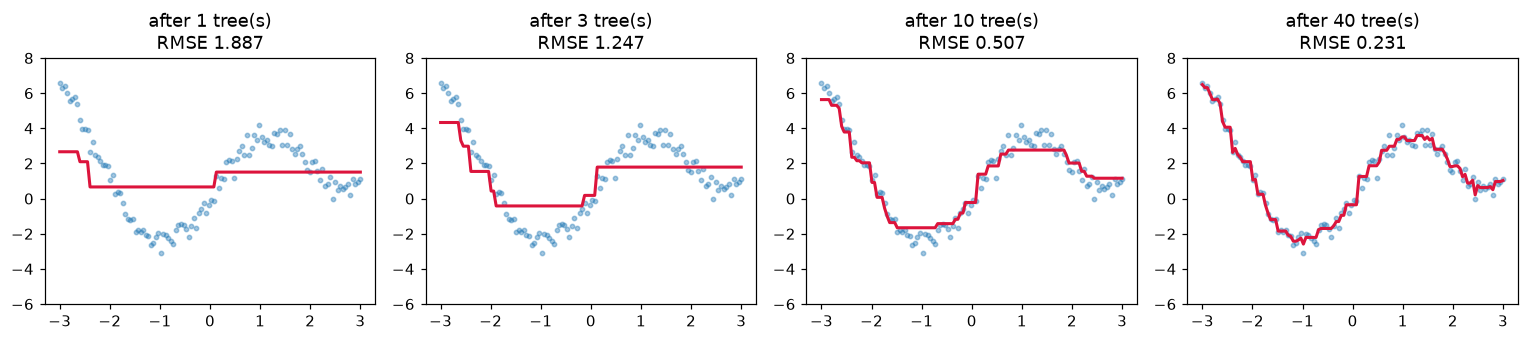

RMSE after 1 tree : 1.8871
RMSE after 40 trees: 0.2307

Each individual tree is a depth-2 stump - it can barely do anything alone. Stacked
forty deep, with each one cleaning up after the last, they trace a curve none of
them could represent.

This is the whole idea. Note it is NOT averaging: the red line is a running SUM.


In [3]:
# Watch it happen on a 1-D problem you can see.
rng = np.random.default_rng(0)
x_demo = np.linspace(-3, 3, 120).reshape(-1, 1)
y_demo = np.sin(x_demo.ravel() * 1.5) * 3 + 0.4 * x_demo.ravel() ** 2
y_demo = y_demo + rng.normal(0, 0.4, len(y_demo))

LR = 0.3
F = np.full(len(y_demo), y_demo.mean())            # F_0: predict the mean, nothing else
stages, snapshots = [], {}

for m in range(1, 41):
    residual = y_demo - F                          # what we still get wrong
    stump = DecisionTreeRegressor(max_depth=2, random_state=RANDOM_STATE).fit(x_demo, residual)
    F = F + LR * stump.predict(x_demo)             # add a SMALL amount of the correction
    stages.append(np.sqrt(np.mean((y_demo - F) ** 2)))
    if m in (1, 3, 10, 40):
        snapshots[m] = F.copy()

fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
for ax, (m, pred) in zip(axes, snapshots.items()):
    ax.scatter(x_demo, y_demo, s=8, alpha=0.4)
    ax.plot(x_demo, pred, color="crimson", lw=2)
    ax.set_title(f"after {m} tree(s)\nRMSE {stages[m-1]:.3f}")
    ax.set_ylim(-6, 8)
fig.tight_layout(); plt.show()

print("RMSE after 1 tree : %.4f" % stages[0])
print("RMSE after 40 trees: %.4f" % stages[-1])
print()
print("Each individual tree is a depth-2 stump - it can barely do anything alone. Stacked")
print("forty deep, with each one cleaning up after the last, they trace a curve none of")
print("them could represent.")
print()
print("This is the whole idea. Note it is NOT averaging: the red line is a running SUM.")

## 1.2 Building it from scratch

The five lines above are the whole algorithm. Let's write it properly and check it against
scikit-learn.

In [4]:
def fit_gradient_boosting(X, y, n_estimators=100, learning_rate=0.1, max_depth=3):
    """Gradient boosting for squared error, from scratch. Returns (F0, trees)."""
    F0 = y.mean()                                  # the initial model: a constant
    F = np.full(len(y), F0)
    trees = []

    for _ in range(n_estimators):
        residual = y - F                           # negative gradient of squared error
        tree = DecisionTreeRegressor(max_depth=max_depth,
                                     random_state=RANDOM_STATE).fit(X, residual)
        F = F + learning_rate * tree.predict(X)    # shrunken update
        trees.append(tree)

    return F0, trees


def predict_gradient_boosting(F0, trees, X, learning_rate=0.1):
    """The prediction is a running sum, not an average."""
    return F0 + learning_rate * np.sum([t.predict(X) for t in trees], axis=0)


rng = np.random.default_rng(0)
X_gb = rng.uniform(-3, 3, size=(400, 3))
y_gb = X_gb[:, 0] ** 2 + 2 * np.sin(X_gb[:, 1] * 2) + 0.5 * X_gb[:, 2] + rng.normal(0, 0.4, 400)
Xg_tr, Xg_te, yg_tr, yg_te = train_test_split(X_gb, y_gb, test_size=0.3,
                                              random_state=RANDOM_STATE)

F0, trees = fit_gradient_boosting(Xg_tr, yg_tr, n_estimators=100, learning_rate=0.1)
mine = predict_gradient_boosting(F0, trees, Xg_te, 0.1)

sk = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3,
                               random_state=RANDOM_STATE).fit(Xg_tr, yg_tr)

print(f"from scratch  test RMSE: {root_mean_squared_error(yg_te, mine):.6f}")
print(f"scikit-learn  test RMSE: {root_mean_squared_error(yg_te, sk.predict(Xg_te)):.6f}")
print(f"\ninitial model F0        : {F0:.6f}")
print(f"sklearn's init_ constant: {float(sk.init_.constant_[0][0]):.6f}   <- identical")
print()
print("The two land on essentially the same performance. They are NOT bit-identical, and")
print("that is worth understanding rather than glossing over: sklearn draws a fresh random")
print("seed per stage (we reuse one) and uses a specialised split criterion, so ties inside")
print("tree construction break differently. The ALGORITHM is the same; the tie-breaking is")
print("not.")

from scratch  test RMSE: 0.747050
scikit-learn  test RMSE: 0.741143

initial model F0        : 2.886138
sklearn's init_ constant: 2.886138   <- identical

The two land on essentially the same performance. They are NOT bit-identical, and
that is worth understanding rather than glossing over: sklearn draws a fresh random
seed per stage (we reuse one) and uses a specialised split criterion, so ties inside
tree construction break differently. The ALGORITHM is the same; the tie-breaking is
not.


In [5]:
# We can verify the additive structure EXACTLY, using sklearn's own trees.
# Claim: F_m(x) = F_0 + learning_rate * sum of the first m tree predictions.
small = GradientBoostingRegressor(n_estimators=50, learning_rate=0.1, max_depth=3,
                                  random_state=RANDOM_STATE).fit(Xg_tr, yg_tr)

F0_sk = float(small.init_.constant_[0][0])
tree_preds = np.array([est[0].predict(Xg_te) for est in small.estimators_])

reconstructed = F0_sk + 0.1 * tree_preds.sum(axis=0)
print(f"max |our reconstruction - sklearn.predict| = "
      f"{np.abs(reconstructed - small.predict(Xg_te)).max():.2e}   <- exact to float precision")

# And at EVERY intermediate stage, which is what staged_predict exposes.
running = F0_sk + 0.1 * np.cumsum(tree_preds, axis=0)
staged = np.array(list(small.staged_predict(Xg_te)))
print(f"matches staged_predict at all {len(staged)} stages: {np.allclose(running, staged)}")

print()
print("That is the proof that a gradient boosting model really is just F0 plus a shrunken")
print("running sum of tree outputs - no averaging, no weighting scheme, nothing hidden.")
print()
print("staged_predict is genuinely useful, not a curiosity: it gives you the ensemble's")
print("prediction after every round for free, which is how early stopping works (1.6).")

max |our reconstruction - sklearn.predict| = 8.88e-15   <- exact to float precision
matches staged_predict at all 50 stages: True

That is the proof that a gradient boosting model really is just F0 plus a shrunken
running sum of tree outputs - no averaging, no weighting scheme, nothing hidden.

staged_predict is genuinely useful, not a curiosity: it gives you the ensemble's
prediction after every round for free, which is how early stopping works (1.6).


## 1.3 Why it is called ***gradient*** boosting

Fitting residuals feels like a trick. It is actually **gradient descent, performed in
function space** — and seeing that is what lets you swap the loss function.

Ordinary gradient descent adjusts *parameters*:
$\;w \leftarrow w - \eta \, \partial L / \partial w$.

Gradient boosting adjusts the *function itself*. Treat the model's prediction
$F(x_i)$ at each training point as the thing being optimised, and take the derivative of the
loss with respect to **it**:

$$ F \leftarrow F - \eta \, \frac{\partial L}{\partial F} $$

For squared error, $L = \tfrac12\sum_i (y_i - F_i)^2$, so:

$$ \frac{\partial L}{\partial F_i} = -(y_i - F_i) \qquad\Longrightarrow\qquad -\frac{\partial L}{\partial F_i} = y_i - F_i = \textbf{the residual} $$

**So "fit the residual" is not a heuristic — it is literally "fit the negative gradient".**
The one extra step is that we cannot update $F$ at arbitrary points, only at the training
rows, so we fit a *tree* to those gradients to get something that generalises.

Change the loss and you change what each tree is fitted to:

| Loss | Used for | Negative gradient ("pseudo-residual") |
|---|---|---|
| Squared error | regression | $y_i - F_i$ — the plain residual |
| Absolute error | robust regression | $\operatorname{sign}(y_i - F_i)$ — only the *direction* |
| Log-loss | classification | $y_i - p_i$, where $p_i = \sigma(F_i)$ |
| Huber | regression with outliers | residual, clipped |

Look at the classification row: $y_i - p_i$ is exactly the gradient from NB-02 §1.3. The same
quantity that drove logistic regression's weights now becomes the target of the next tree.

In [6]:
# The claim, checked numerically: fitting the residual == fitting the negative gradient.
y_true = np.array([3.0, -1.0, 4.0, 0.5])
F_now = np.array([2.0, 0.0, 4.5, 0.0])

def squared_error_loss(F):
    return 0.5 * np.sum((y_true - F) ** 2)

# Numerical gradient of the loss with respect to each PREDICTION.
eps = 1e-6
numerical = np.array([
    (squared_error_loss(F_now + eps * np.eye(len(F_now))[i])
     - squared_error_loss(F_now - eps * np.eye(len(F_now))[i])) / (2 * eps)
    for i in range(len(F_now))
])

print("residual        (y - F) :", y_true - F_now)
print("negative gradient -dL/dF:", -numerical.round(6))
print("identical               :", np.allclose(y_true - F_now, -numerical))
print()

# And the classification case: the pseudo-residual is y - p.
from scipy.special import expit
y_cls = np.array([1, 0, 1, 0])
F_cls = np.array([0.4, -0.2, 1.5, 0.8])          # log-odds, not probabilities

def log_loss_raw(F):
    p = expit(F)
    return -np.sum(y_cls * np.log(p) + (1 - y_cls) * np.log(1 - p))

numerical_cls = np.array([
    (log_loss_raw(F_cls + eps * np.eye(4)[i]) - log_loss_raw(F_cls - eps * np.eye(4)[i]))
    / (2 * eps) for i in range(4)
])
print("y - sigmoid(F)          :", (y_cls - expit(F_cls)).round(6))
print("negative gradient -dL/dF:", -numerical_cls.round(6))
print("identical               :", np.allclose(y_cls - expit(F_cls), -numerical_cls))
print()
print("Same story for classification: each tree is fitted to (actual - predicted")
print("probability). Boosting operates on the LOG-ODDS scale and squashes at the end,")
print("exactly like logistic regression - which is why GradientBoostingClassifier has a")
print("`predict_proba` that behaves sensibly.")

residual        (y - F) : [ 1.  -1.  -0.5  0.5]
negative gradient -dL/dF: [ 1.  -1.  -0.5  0.5]
identical               : True

y - sigmoid(F)          : [ 0.401312 -0.450166  0.182426 -0.689974]
negative gradient -dL/dF: [ 0.401312 -0.450166  0.182426 -0.689974]
identical               : True

Same story for classification: each tree is fitted to (actual - predicted
probability). Boosting operates on the LOG-ODDS scale and squashes at the end,
exactly like logistic regression - which is why GradientBoostingClassifier has a
`predict_proba` that behaves sensibly.


## 1.4 The learning rate and `n_estimators` are one dial, not two

This is the single most common tuning mistake in boosting.

The learning rate $\eta$ shrinks every tree's contribution. Halve it and you need roughly
twice as many trees to travel the same distance. So they trade off directly — but **not
symmetrically**, and the asymmetry is the useful part:

- **High $\eta$** — fast, few trees needed, but each step is crude. It converges to a
  *worse* solution and cannot be rescued by adding trees.
- **Low $\eta$** — each step is a small careful correction, so the ensemble ends up better.
  The cost is compute: you need many more rounds.

**Tune them together, and never tune `n_estimators` alone.** The standard recipe is: fix a
small learning rate you can afford (0.01–0.1), then use early stopping to choose the number
of trees for you (1.6).

In [7]:
grid_n = [10, 50, 200, 1000]
print(f"{'learning_rate':>14}" + "".join(f"{n:>10}" for n in grid_n) + "   (test RMSE)")
print("-" * 60)
curves = {}
for lr in [0.5, 0.1, 0.03]:
    row = []
    for n in grid_n:
        m = GradientBoostingRegressor(n_estimators=n, learning_rate=lr, max_depth=3,
                                      random_state=RANDOM_STATE).fit(Xg_tr, yg_tr)
        row.append(root_mean_squared_error(yg_te, m.predict(Xg_te)))
    curves[lr] = row
    print(f"{lr:>14}" + "".join(f"{v:>10.4f}" for v in row))

best_high = min(curves[0.5])
best_low = min(curves[0.1])
print()
print(f"lr=0.5  gets close quickly but bottoms out at {best_high:.4f} and STAYS there -")
print("        adding trees from 200 to 1000 changes almost nothing. The steps are too")
print("        coarse to find a better solution, and more of them will not fix that.")
print(f"lr=0.1  reaches {best_low:.4f}, clearly better, and needs ~200 trees to get there.")
print("lr=0.03 is still improving at 1000 trees - correct direction, not enough budget.")
print()
print("The shape to remember: SMALLER learning rate -> better final model, more trees")
print("needed. The floor is set by the learning rate; the trees just get you to it.")

 learning_rate        10        50       200      1000   (test RMSE)
------------------------------------------------------------
           0.5    1.0572    0.9513    0.9447    0.9440
           0.1    1.8748    0.8868    0.7114    0.7111
          0.03    2.6625    1.6126    0.8592    0.7243

lr=0.5  gets close quickly but bottoms out at 0.9440 and STAYS there -
        adding trees from 200 to 1000 changes almost nothing. The steps are too
        coarse to find a better solution, and more of them will not fix that.
lr=0.1  reaches 0.7111, clearly better, and needs ~200 trees to get there.
lr=0.03 is still improving at 1000 trees - correct direction, not enough budget.

The shape to remember: SMALLER learning rate -> better final model, more trees
needed. The floor is set by the learning rate; the trees just get you to it.


## 1.5 Why the trees are shallow — the exact opposite of NB-04

NB-04 §1.6 concluded: inside a random forest, leave the trees **unpruned**, because averaging
removes variance but cannot remove bias, so you want low-bias base learners.

Boosting inverts every part of that sentence.

- Boosting reduces **bias** — it keeps adding corrections until the training data is fitted.
- So what it *cannot* fix is **variance**, and deep trees are exactly where variance comes from.
- Therefore the base learners should be **weak, high-bias, low-variance**: stumps or
  depth-2/3 trees.

There is a second reason, and it is the more useful one in practice: **`max_depth` controls
the interaction order the ensemble can represent.** A depth-1 stump splits on one feature, so
the model is purely additive — it can never represent "A matters only when B is high". Depth 2
allows pairwise interactions, depth 3 three-way, and so on. So you are not just setting
capacity, you are declaring how complex the interactions in your data are.

In [8]:
print("the SAME base learner depth, in both ensembles (test RMSE)\n")
print(f"{'max_depth':>10} {'gradient boosting':>19} {'random forest':>16}")
print("-" * 50)
for depth in [1, 2, 3, 6, None]:
    gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=depth,
                                   random_state=RANDOM_STATE).fit(Xg_tr, yg_tr)
    rf = RandomForestRegressor(n_estimators=200, max_depth=depth,
                               random_state=RANDOM_STATE, n_jobs=-1).fit(Xg_tr, yg_tr)
    print(f"{str(depth):>10} {root_mean_squared_error(yg_te, gb.predict(Xg_te)):>19.4f} "
          f"{root_mean_squared_error(yg_te, rf.predict(Xg_te)):>16.4f}")

print()
print("The two columns run in OPPOSITE directions. The forest improves monotonically as the")
print("trees get deeper. Boosting has a clear optimum at shallow depth and then degrades")
print("badly - by max_depth=None it is worse than the forest, having started far better.")
print()
print("Put the two notebooks' advice side by side:")
print("  random forest    -> deep, unpruned trees. Averaging kills the variance.")
print("  gradient boosting-> shallow trees. Nothing kills variance, so do not create it.")
print()
print("If you remember one thing from this section: a hyperparameter's correct value depends")
print("on what the ENSEMBLE does with the base learner, not on the base learner alone.")

the SAME base learner depth, in both ensembles (test RMSE)

 max_depth   gradient boosting    random forest
--------------------------------------------------
         1              0.9856           2.7300
         2              0.6907           1.9877
         3              0.7114           1.7330
         6              1.2972           1.4686
      None              1.7596           1.3537

The two columns run in OPPOSITE directions. The forest improves monotonically as the
trees get deeper. Boosting has a clear optimum at shallow depth and then degrades
badly - by max_depth=None it is worse than the forest, having started far better.

Put the two notebooks' advice side by side:
  random forest    -> deep, unpruned trees. Averaging kills the variance.
  gradient boosting-> shallow trees. Nothing kills variance, so do not create it.

If you remember one thing from this section: a hyperparameter's correct value depends
on what the ENSEMBLE does with the base learner, not on the bas

## 1.6 Early stopping: the parameter a forest does not need

NB-04 §1.5 established that `n_estimators` is one of the few hyperparameters you cannot set
too high — for a **forest**. Boosting is the counter-example, and the reason is structural:
each tree is fitted to the *current* ensemble's errors, so once the real signal is exhausted,
further rounds fit noise and the ensemble keeps moving in that direction.

The fix is **early stopping**: watch performance on held-out data each round, and stop when
it stops improving. Every serious implementation supports it.

| Implementation | How |
|---|---|
| sklearn `GradientBoosting*` | `validation_fraction=0.1, n_iter_no_change=10` |
| sklearn `HistGradientBoosting*` | `early_stopping=True` (on by default for large data) |
| XGBoost | `early_stopping_rounds=` + `eval_set=` |
| LightGBM | `callbacks=[lgb.early_stopping(50)]` |
| CatBoost | `od_type="Iter", od_wait=50` |

**The validation data must come from the training set**, never the test set — selecting the
number of rounds *is* model selection (Foundations §3.5).

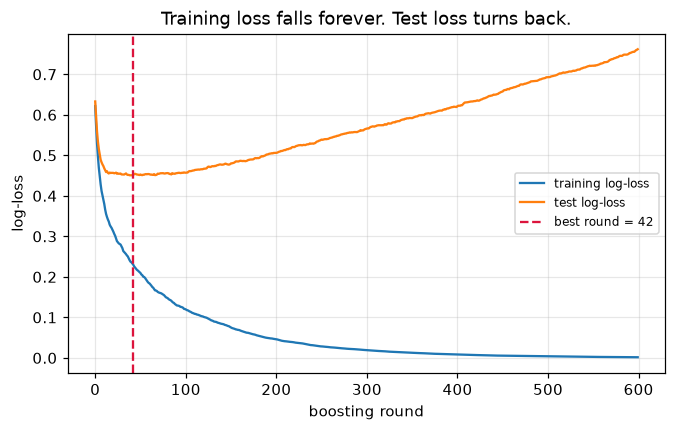

best test log-loss 0.4508 at round 42
test log-loss at round 600: 0.7619   (+69% worse)

The training curve never turns - it cannot, because every tree is fitted to reduce
exactly that quantity. Only held-out data reveals the turning point.

Run the same experiment on a random forest and the test curve flattens instead of
rising. That difference is the whole reason this parameter is dangerous here and
free there.


In [9]:
# Noisy data, so the overfitting is unmistakable.
X_noisy, y_noisy = make_classification(n_samples=2500, n_features=20, n_informative=6,
                                       flip_y=0.20, random_state=RANDOM_STATE)
Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(X_noisy, y_noisy, test_size=0.3,
                                              stratify=y_noisy, random_state=RANDOM_STATE)

deep_boost = GradientBoostingClassifier(n_estimators=600, learning_rate=0.2, max_depth=4,
                                        random_state=RANDOM_STATE).fit(Xn_tr, yn_tr)

# staged_decision_function gives the ensemble at every round, for free.
train_loss, test_loss = [], []
for s_tr, s_te in zip(deep_boost.staged_decision_function(Xn_tr),
                      deep_boost.staged_decision_function(Xn_te)):
    train_loss.append(log_loss(yn_tr, expit(s_tr.ravel())))
    test_loss.append(log_loss(yn_te, expit(s_te.ravel())))

best_round = int(np.argmin(test_loss)) + 1
plt.plot(train_loss, label="training log-loss")
plt.plot(test_loss, label="test log-loss")
plt.axvline(best_round, ls="--", color="crimson", label=f"best round = {best_round}")
plt.xlabel("boosting round"); plt.ylabel("log-loss")
plt.title("Training loss falls forever. Test loss turns back.")
plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.show()

print(f"best test log-loss {min(test_loss):.4f} at round {best_round}")
print(f"test log-loss at round 600: {test_loss[-1]:.4f}   "
      f"({test_loss[-1] / min(test_loss) - 1:+.0%} worse)")
print()
print("The training curve never turns - it cannot, because every tree is fitted to reduce")
print("exactly that quantity. Only held-out data reveals the turning point.")
print()
print("Run the same experiment on a random forest and the test curve flattens instead of")
print("rising. That difference is the whole reason this parameter is dangerous here and")
print("free there.")

In [10]:
# Doing it properly - sklearn carves the validation set out of the training data itself.
auto = GradientBoostingClassifier(
    n_estimators=600, learning_rate=0.2, max_depth=4,
    validation_fraction=0.15,      # 15% of TRAINING data, held out internally
    n_iter_no_change=20,           # stop after 20 rounds without improvement
    random_state=RANDOM_STATE,
).fit(Xn_tr, yn_tr)

fixed = GradientBoostingClassifier(n_estimators=600, learning_rate=0.2, max_depth=4,
                                   random_state=RANDOM_STATE).fit(Xn_tr, yn_tr)

print(f"{'model':<38} {'trees used':>11} {'test log-loss':>15} {'test AUC':>10}")
print("-" * 78)
for label, model in [("fixed 600 rounds", fixed), ("early stopping", auto)]:
    p = model.predict_proba(Xn_te)[:, 1]
    n_used = model.n_estimators_
    print(f"{label:<38} {n_used:>11} {log_loss(yn_te, p):>15.4f} "
          f"{roc_auc_score(yn_te, p):>10.4f}")

print()
print(f"Early stopping used {auto.n_estimators_} of the 600 available rounds and cut the")
print("test log-loss by roughly a third, in a fraction of the fitting time. It found that")
print("stopping point WITHOUT ever touching the test set - the validation slice came out")
print("of the training data.")
print()
print("Look carefully at the AUC column, though: it barely moved, and may even be a hair")
print("lower. That is not a contradiction, it is a distinction worth internalising:")
print()
print("  AUC measures RANKING. Those 550 extra rounds did not reorder the customers much.")
print("  Log-loss measures the PROBABILITIES. Those extra rounds pushed them towards 0")
print("  and 1 far past what the evidence supports - confidently wrong, which log-loss")
print("  punishes and AUC cannot see at all (NB-02 Q6).")
print()
print("So overfitting in boosting often shows up as DESTROYED CALIBRATION before it shows")
print("up as degraded ranking. If you monitor only AUC you will miss it. Watch log-loss.")
print()
print("Set n_estimators generously and let early stopping decide. Treat it as a budget,")
print("not as a tuning parameter.")

model                                   trees used   test log-loss   test AUC
------------------------------------------------------------------------------
fixed 600 rounds                               600          0.7619     0.8633
early stopping                                  49          0.4634     0.8622

Early stopping used 49 of the 600 available rounds and cut the
test log-loss by roughly a third, in a fraction of the fitting time. It found that
stopping point WITHOUT ever touching the test set - the validation slice came out
of the training data.

Look carefully at the AUC column, though: it barely moved, and may even be a hair
lower. That is not a contradiction, it is a distinction worth internalising:

  AUC measures RANKING. Those 550 extra rounds did not reorder the customers much.
  Log-loss measures the PROBABILITIES. Those extra rounds pushed them towards 0
  and 1 far past what the evidence supports - confidently wrong, which log-loss
  punishes and AUC cannot see at

## 1.7 Where boosting is worst: noisy labels

Every strength has a matching weakness, and boosting's follows directly from the mechanism.

If a training row is **mislabelled**, the ensemble will keep getting it wrong, so it keeps
producing a large residual, so **every subsequent tree is pulled towards it**. Boosting
chases its hardest examples by design — and a mislabelled row is the hardest example there
is.

A random forest has no such feedback loop. Each tree sees the bad row (or not, thanks to
bootstrapping), gets it wrong, and no other tree ever hears about it.

In [11]:
print("test accuracy as label noise increases\n")
print(f"{'flip_y':>8} {'gradient boosting':>19} {'random forest':>16} {'gap':>9}")
print("-" * 56)
for flip in [0.0, 0.10, 0.25, 0.40]:
    Xf, yf = make_classification(n_samples=2000, n_features=12, n_informative=6,
                                 flip_y=flip, random_state=RANDOM_STATE)
    Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(Xf, yf, test_size=0.3, stratify=yf,
                                                  random_state=RANDOM_STATE)
    gb = GradientBoostingClassifier(n_estimators=300, learning_rate=0.1, max_depth=3,
                                    random_state=RANDOM_STATE).fit(Xf_tr, yf_tr)
    rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE,
                                n_jobs=-1).fit(Xf_tr, yf_tr)
    g, r = gb.score(Xf_te, yf_te), rf.score(Xf_te, yf_te)
    print(f"{flip:>8} {g:>19.4f} {r:>16.4f} {g - r:>+9.4f}")

print()
print("The forest wins at every noise level, and the gap WIDENS as noise increases. That is")
print("the feedback loop showing up in the numbers.")
print()
print("What to do when your labels are noisy:")
print("  - lower the learning rate (smaller steps towards the bad rows)")
print("  - use early stopping aggressively (stop before it starts chasing them)")
print("  - raise min_samples_leaf / min_child_weight (a leaf cannot form around one row)")
print("  - use subsample < 1.0 (stochastic boosting - each round sees a different sample)")
print("  - consider a robust loss ('huber' / 'absolute_error' for regression)")
print("  - or just use a random forest, which is what this table suggests")
print()
print("And before any of that: go and look at the rows the model gets most wrong. On real")
print("data, a handful of them are usually mislabelled, and fixing the DATA beats every")
print("hyperparameter on this list.")

test accuracy as label noise increases

  flip_y   gradient boosting    random forest       gap
--------------------------------------------------------
     0.0              0.9317           0.9367   -0.0050
     0.1              0.8667           0.8750   -0.0083
    0.25              0.7850           0.8050   -0.0200
     0.4              0.7067           0.7450   -0.0383

The forest wins at every noise level, and the gap WIDENS as noise increases. That is
the feedback loop showing up in the numbers.

What to do when your labels are noisy:
  - lower the learning rate (smaller steps towards the bad rows)
  - use early stopping aggressively (stop before it starts chasing them)
  - raise min_samples_leaf / min_child_weight (a leaf cannot form around one row)
  - use subsample < 1.0 (stochastic boosting - each round sees a different sample)
  - consider a robust loss ('huber' / 'absolute_error' for regression)
  - or just use a random forest, which is what this table suggests

And before

***
# Part 2 - XGBoost, LightGBM and CatBoost

Everything in Part 1 was sklearn's `GradientBoostingClassifier`, which implements Friedman's
original algorithm faithfully and is **too slow to use in practice**. The three libraries
that replaced it are not different algorithms — they are the same algorithm with a different
engineering approach, plus a handful of genuinely useful additions.

This part covers what actually differs, so you can choose deliberately rather than by habit.

## 2.1 The one change that matters: histogram binning

Recall NB-03 §1.2: to find a split, a tree evaluates **every feature × every candidate
threshold**. With continuous features and $n$ rows, that is $O(n)$ thresholds per feature,
per node, and it is where essentially all the fitting time goes.

The insight behind every modern library: **bin the features first.** Sort each feature once,
bucket its values into (say) 256 bins, and only ever consider bin boundaries as split points.

- Threshold candidates per feature drop from $n$ to ~255, regardless of dataset size.
- Histograms can be built incrementally: a node's histogram is its parent's minus its
  sibling's, so one child is nearly free.
- Binned values fit in one byte, so the data is small and cache-friendly.

You lose the ability to split at an exact arbitrary value. In practice that costs almost
nothing — and sklearn's own `HistGradientBoosting*` implements it, so you get the speed
without an extra dependency.

In [12]:
# The same problem, the same hyperparameters, five implementations.
X_speed, y_speed = make_classification(
    n_samples=12_000, n_features=25, n_informative=10, n_redundant=5,
    weights=[0.85, 0.15], random_state=RANDOM_STATE)
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(
    X_speed, y_speed, test_size=0.25, stratify=y_speed, random_state=RANDOM_STATE)

N_TREES, LR, DEPTH = 200, 0.1, 6

contenders = [
    ("sklearn GradientBoosting (exact)",
     GradientBoostingClassifier(n_estimators=N_TREES, learning_rate=LR, max_depth=DEPTH,
                                random_state=RANDOM_STATE)),
    ("sklearn HistGradientBoosting",
     HistGradientBoostingClassifier(max_iter=N_TREES, learning_rate=LR, max_depth=DEPTH,
                                    early_stopping=False, random_state=RANDOM_STATE)),
]
if xgb is not None:
    contenders.append(("XGBoost", xgb.XGBClassifier(
        n_estimators=N_TREES, learning_rate=LR, max_depth=DEPTH, tree_method="hist",
        random_state=RANDOM_STATE, verbosity=0)))
if lgb is not None:
    contenders.append(("LightGBM", lgb.LGBMClassifier(
        n_estimators=N_TREES, learning_rate=LR, max_depth=DEPTH,
        random_state=RANDOM_STATE, verbose=-1)))
if cb is not None:
    contenders.append(("CatBoost", cb.CatBoostClassifier(
        iterations=N_TREES, learning_rate=LR, depth=DEPTH,
        random_seed=RANDOM_STATE, verbose=0)))

print(f"{len(Xs_tr):,} training rows x {X_speed.shape[1]} features, "
      f"{N_TREES} trees, depth {DEPTH}\n")
print(f"{'implementation':<36} {'seconds':>9} {'test AUC':>10} {'speedup':>9}")
print("-" * 68)
timings = {}
for name, model in contenders:
    t0 = time.time()
    model.fit(Xs_tr, ys_tr)
    elapsed = time.time() - t0
    timings[name] = elapsed
    auc = roc_auc_score(ys_te, model.predict_proba(Xs_te)[:, 1])
    speedup = timings["sklearn GradientBoosting (exact)"] / elapsed
    print(f"{name:<36} {elapsed:>9.2f} {auc:>10.4f} {speedup:>8.0f}x")

print()
print("Read the AUC column first: they are all within a few thousandths of each other. The")
print("binning approximation costs essentially nothing in accuracy.")
print()
print("Now read the time column. That is the entire reason nobody uses the exact")
print("implementation any more - and the gap grows with dataset size, because the exact")
print("version scales with the number of distinct values while the binned ones do not.")

9,000 training rows x 25 features, 200 trees, depth 6

implementation                         seconds   test AUC   speedup
--------------------------------------------------------------------
sklearn GradientBoosting (exact)         27.59     0.9683        1x
sklearn HistGradientBoosting              0.87     0.9731       32x
XGBoost                                   0.67     0.9734       41x
LightGBM                                  0.53     0.9704       52x
CatBoost                                  2.24     0.9758       12x

Read the AUC column first: they are all within a few thousandths of each other. The
binning approximation costs essentially nothing in accuracy.

Now read the time column. That is the entire reason nobody uses the exact
implementation any more - and the gap grows with dataset size, because the exact
version scales with the number of distinct values while the binned ones do not.


## 2.2 What genuinely differs between the three

The libraries are much more alike than the internet suggests. Here is what is real.

### Tree growth: level-wise vs leaf-wise

- **XGBoost (default) and CatBoost** grow **level-wise** (depth-wise): expand every node at
  the current depth before going deeper. Produces balanced trees; `max_depth` means what you
  expect.
- **LightGBM** grows **leaf-wise** (best-first): always split whichever leaf promises the
  largest loss reduction, wherever it is. Produces deep, lopsided trees that reach a lower
  loss for the same number of leaves — and **overfit more readily**.

That single difference explains LightGBM's reputation for being both fastest and easiest to
overfit. With LightGBM, **`num_leaves` is the real capacity control**, not `max_depth`, and
the default of 31 is aggressive on small data.

### Categorical features

| Library | Approach |
|---|---|
| XGBoost | `enable_categorical=True` with pandas `category` dtype (partition-based splits) |
| LightGBM | `categorical_feature=` — sorts categories by gradient statistics, then splits |
| CatBoost | **Ordered target statistics** — replaces each category with a target mean computed only from *previous* rows in a random permutation, which is a principled defence against the leakage that plain target encoding causes |
| sklearn Hist | `categorical_features=` — similar to LightGBM |

CatBoost's approach is its main claim to fame and genuinely helps on high-cardinality columns.

### Missing values

All four learn a **default direction** per split: NaN goes left or right depending on which
reduced the loss during training. No imputation required, and missingness becomes usable
signal. (This is strictly better than what Foundations §5.1 has to do for a linear model.)

### Regularisation

XGBoost exposes the most explicit knobs — `reg_lambda` (L2 on leaf weights), `reg_alpha`
(L1), `gamma` (minimum loss reduction to split). Its objective genuinely includes those
penalty terms, which is the "regularized" in the paper's title.

In [13]:
# Leaf-wise vs level-wise, made concrete.
if lgb is not None and xgb is not None:
    print("same nominal depth, very different tree shapes\n")
    lgb_model = lgb.LGBMClassifier(n_estimators=50, num_leaves=31, max_depth=-1,
                                   random_state=RANDOM_STATE, verbose=-1).fit(Xs_tr, ys_tr)
    lgb_capped = lgb.LGBMClassifier(n_estimators=50, num_leaves=8, max_depth=-1,
                                    random_state=RANDOM_STATE, verbose=-1).fit(Xs_tr, ys_tr)
    xgb_model = xgb.XGBClassifier(n_estimators=50, max_depth=3, tree_method="hist",
                                  random_state=RANDOM_STATE, verbosity=0).fit(Xs_tr, ys_tr)

    info = lgb_model.booster_.dump_model()["tree_info"]
    leaves = [t["num_leaves"] for t in info]
    info2 = lgb_capped.booster_.dump_model()["tree_info"]
    print(f"LightGBM num_leaves=31 : mean {np.mean(leaves):.1f} leaves per tree "
          f"(unbounded depth)")
    print(f"LightGBM num_leaves=8  : mean "
          f"{np.mean([t['num_leaves'] for t in info2]):.1f} leaves per tree")
    print(f"XGBoost  max_depth=3   : at most {2**3} leaves per tree (balanced)")
    print()
    print(f"{'model':<28} {'test AUC':>10}")
    print("-" * 40)
    for label, m in [("LightGBM num_leaves=31", lgb_model),
                     ("LightGBM num_leaves=8", lgb_capped),
                     ("XGBoost max_depth=3", xgb_model)]:
        print(f"{label:<28} {roc_auc_score(ys_te, m.predict_proba(Xs_te)[:, 1]):>10.4f}")
    print()
    print("A leaf-wise tree with 31 leaves can be far deeper than a level-wise tree with 31")
    print("leaves, because it spends them all down one branch if that is where the loss is.")
    print("More expressive per leaf - which is why LightGBM tends to win on large data.")
    print()
    print("Note that on THIS data, turning num_leaves down to 8 clearly HURT. That is the")
    print("expected result here: 9,000 clean rows with real structure can support the extra")
    print("capacity. num_leaves is the first thing to turn DOWN when you are overfitting -")
    print("small samples, noisy labels, a train/test gap - and not a reflex otherwise.")
    print()
    print("The transferable point is which knob to reach for: in LightGBM, capacity lives in")
    print("num_leaves, not max_depth (which defaults to unlimited). Turning max_depth down")
    print("in LightGBM often does nothing at all.")
else:
    print("LightGBM and/or XGBoost not installed - skipping the tree-shape comparison.")

same nominal depth, very different tree shapes

LightGBM num_leaves=31 : mean 31.0 leaves per tree (unbounded depth)
LightGBM num_leaves=8  : mean 8.0 leaves per tree
XGBoost  max_depth=3   : at most 8 leaves per tree (balanced)

model                          test AUC
----------------------------------------
LightGBM num_leaves=31           0.9707
LightGBM num_leaves=8            0.9537
XGBoost max_depth=3              0.9589

A leaf-wise tree with 31 leaves can be far deeper than a level-wise tree with 31
leaves, because it spends them all down one branch if that is where the loss is.
More expressive per leaf - which is why LightGBM tends to win on large data.

Note that on THIS data, turning num_leaves down to 8 clearly HURT. That is the
expected result here: 9,000 clean rows with real structure can support the extra
capacity. num_leaves is the first thing to turn DOWN when you are overfitting -
small samples, noisy labels, a train/test gap - and not a reflex otherwise.

The transfe

In [14]:
# Categorical handling on a genuinely high-cardinality column.
rng = np.random.default_rng(0)
n_cat = 20_000
category = rng.integers(0, 60, n_cat)                 # 60 levels
cat_effect = rng.normal(0, 1.5, 60)[category]         # each level shifts the odds
numeric = rng.normal(size=n_cat)
y_cat = (rng.random(n_cat) < expit(cat_effect + numeric)).astype(int)

frame = pd.DataFrame({"category": category, "numeric": numeric})
Xk_tr, Xk_te, yk_tr, yk_te = train_test_split(frame, y_cat, test_size=0.3,
                                              stratify=y_cat, random_state=RANDOM_STATE)

results = []
# (a) one-hot: 60 extra columns
onehot = pd.get_dummies(frame["category"].astype("category"), prefix="cat")
Xoh = pd.concat([onehot, frame["numeric"]], axis=1)
Xo_tr, Xo_te, _, _ = train_test_split(Xoh, y_cat, test_size=0.3, stratify=y_cat,
                                      random_state=RANDOM_STATE)
m = HistGradientBoostingClassifier(max_iter=300, random_state=RANDOM_STATE).fit(Xo_tr, yk_tr)
results.append(("one-hot (60 extra columns)",
                roc_auc_score(yk_te, m.predict_proba(Xo_te)[:, 1])))

if lgb is not None:
    a, b = Xk_tr.copy(), Xk_te.copy()
    a["category"] = a["category"].astype("category")
    b["category"] = b["category"].astype("category")
    m = lgb.LGBMClassifier(n_estimators=300, random_state=RANDOM_STATE,
                           verbose=-1).fit(a, yk_tr, categorical_feature=["category"])
    results.append(("LightGBM native categorical",
                    roc_auc_score(yk_te, m.predict_proba(b)[:, 1])))

if cb is not None:
    a, b = Xk_tr.astype({"category": str}), Xk_te.astype({"category": str})
    m = cb.CatBoostClassifier(iterations=300, random_seed=RANDOM_STATE, verbose=0,
                              cat_features=["category"]).fit(a, yk_tr)
    results.append(("CatBoost ordered target stats",
                    roc_auc_score(yk_te, m.predict_proba(b)[:, 1])))

print(f"60-level categorical + 1 numeric feature, {n_cat:,} rows\n")
print(f"{'approach':<34} {'test AUC':>10}")
print("-" * 46)
for label, auc in results:
    print(f"{label:<34} {auc:>10.4f}")
print()
print("CatBoost's ordered target statistics wins here, which is the case it was designed")
print("for. Note the honest part: LightGBM's native handling is NOT automatically better")
print("than one-hot - on this data it is slightly behind.")
print()
print("Native categorical support is worth reaching for when cardinality is high enough that")
print("one-hot becomes unwieldy, not as a reflex. Measure it like anything else.")

60-level categorical + 1 numeric feature, 20,000 rows

approach                             test AUC
----------------------------------------------
one-hot (60 extra columns)             0.8334
LightGBM native categorical            0.8208
CatBoost ordered target stats          0.8369

CatBoost's ordered target statistics wins here, which is the case it was designed
for. Note the honest part: LightGBM's native handling is NOT automatically better
than one-hot - on this data it is slightly behind.

Native categorical support is worth reaching for when cardinality is high enough that
one-hot becomes unwieldy, not as a reflex. Measure it like anything else.


## 2.3 Which one should you use?

| Situation | Reach for |
|---|---|
| **Starting out / no extra dependencies wanted** | `HistGradientBoosting*` — already in sklearn, genuinely competitive |
| **Largest datasets, fastest iteration** | **LightGBM** — usually the quickest to fit. Turn `num_leaves` down |
| **Most mature, most deployment targets, best docs** | **XGBoost** — the safest institutional choice |
| **Many high-cardinality categoricals** | **CatBoost** — ordered target statistics, and the best defaults of the three |
| **Small data (< ~1000 rows)** | Consider not boosting at all — a forest or a regularised linear model is often better and far less fiddly |

**The honest summary:** on most problems, well-tuned versions of all four land within noise
of each other, and the choice matters far less than your features, your validation scheme and
your learning rate. Benchmark papers that crown a winner are usually measuring default
hyperparameters, which is a statement about defaults, not algorithms.

Pick one, learn its parameters properly, and spend the saved time on the data.

***
# Part 3 - Worked example, with honest tuning

Boosting is the first model in this series where **tuning is not optional**. A forest's
defaults are good; boosting's are a starting point.

The workflow is Foundations Part 1. What is boosting-specific is the tuning strategy, so that
is where we spend the time.

In [15]:
X_wk, y_wk = make_classification(
    n_samples=8000, n_features=20, n_informative=8, n_redundant=4,
    weights=[0.88, 0.12], flip_y=0.02, class_sep=0.9, random_state=RANDOM_STATE)
X_wk = pd.DataFrame(X_wk, columns=[f"f{i:02d}" for i in range(20)])

Xw_tr, Xw_te, yw_tr, yw_te = train_test_split(
    X_wk, y_wk, test_size=0.25, stratify=y_wk, random_state=RANDOM_STATE)

print(f"{len(X_wk):,} rows x {X_wk.shape[1]} features, positive rate {y_wk.mean():.3f}")
print(f"train {len(Xw_tr)}  test {len(Xw_te)}")

dummy = DummyClassifier(strategy="most_frequent").fit(Xw_tr, yw_tr)
print(f"\nbaseline accuracy {dummy.score(Xw_te, yw_te):.4f}, AUC 0.5000")

cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
default = HistGradientBoostingClassifier(random_state=RANDOM_STATE)
base_scores = cross_val_score(default, Xw_tr, yw_tr, cv=cv, scoring="roc_auc")
print(f"\nout-of-the-box HistGradientBoosting CV AUC: "
      f"{base_scores.mean():.4f} (+/- {base_scores.std():.4f})")
print("That is the number tuning has to beat.")

8,000 rows x 20 features, positive rate 0.128
train 6000  test 2000

baseline accuracy 0.8725, AUC 0.5000

out-of-the-box HistGradientBoosting CV AUC: 0.9442 (+/- 0.0077)
That is the number tuning has to beat.


### The tuning strategy that works

Do **not** throw every parameter into one giant grid. They fall into three groups with
different jobs, and the order matters:

1. **Fix the learning rate low and the trees generous, then let early stopping pick the
   count.** `learning_rate=0.05`, large `max_iter`, `early_stopping=True`. This removes
   `n_estimators` from the search entirely (§1.4, §1.6).
2. **Tune capacity** — `max_leaf_nodes` / `num_leaves` / `max_depth`, and
   `min_samples_leaf` / `min_child_weight`. This is where most of the gain is.
3. **Tune regularisation last** — `l2_regularization`, `subsample`, `colsample_bytree`.
   Usually worth a small amount.

Use `RandomizedSearchCV`, not `GridSearchCV` — with this many interacting parameters, random
sampling finds a better optimum for the same budget (Foundations §8).

In [16]:
search_space = {
    "max_leaf_nodes": [7, 15, 31, 63],
    "min_samples_leaf": [5, 10, 20, 50],
    "l2_regularization": [0.0, 0.1, 1.0, 10.0],
    "max_features": [0.5, 0.7, 1.0],
}

tuned_search = RandomizedSearchCV(
    HistGradientBoostingClassifier(
        learning_rate=0.05,            # fixed low (step 1)
        max_iter=1000,                 # generous budget...
        early_stopping=True,           # ...and let early stopping use what it needs
        n_iter_no_change=20,
        validation_fraction=0.15,
        random_state=RANDOM_STATE,
    ),
    param_distributions=search_space,
    n_iter=25, cv=cv, scoring="roc_auc",
    random_state=RANDOM_STATE, n_jobs=-1,
).fit(Xw_tr, yw_tr)

print("best parameters:")
for k, v in sorted(tuned_search.best_params_.items()):
    print(f"  {k:<22} {v}")

gain = tuned_search.best_score_ - base_scores.mean()
print(f"\nCV AUC: default {base_scores.mean():.4f}  ->  tuned "
      f"{tuned_search.best_score_:.4f}   ({gain:+.4f})")

best = tuned_search.best_estimator_
print(f"early stopping used {best.n_iter_} of the 1000 available rounds")

print()
print("NOW READ THAT GAIN AGAINST ITS OWN ERROR BAR, before believing it:")
print(f"  improvement            {gain:+.4f}")
print(f"  CV std of the default  +/-{base_scores.std():.4f}")
print()
if gain < base_scores.std():
    print("  The 'improvement' is SMALLER than the fold-to-fold standard deviation.")
    print("  That is not a result. It is noise wearing a result's clothing.")
else:
    print("  The improvement clears the fold-to-fold noise - worth taking seriously.")
print()
print("There is a second, sharper problem with reading best_score_ as an achievement:")
print("RandomizedSearchCV tried 25 configurations and reported the best one. Taking the")
print("maximum of 25 noisy numbers is biased upward even if every configuration were")
print("identical - the same selection effect as Foundations 3.5 and 8.1. The honest")
print("estimate of the tuned model is the TEST score, which we look at next.")

best parameters:
  l2_regularization      0.1
  max_features           0.7
  max_leaf_nodes         63
  min_samples_leaf       5

CV AUC: default 0.9442  ->  tuned 0.9492   (+0.0050)
early stopping used 118 of the 1000 available rounds

NOW READ THAT GAIN AGAINST ITS OWN ERROR BAR, before believing it:
  improvement            +0.0050
  CV std of the default  +/-0.0077

  The 'improvement' is SMALLER than the fold-to-fold standard deviation.
  That is not a result. It is noise wearing a result's clothing.

There is a second, sharper problem with reading best_score_ as an achievement:
RandomizedSearchCV tried 25 configurations and reported the best one. Taking the
maximum of 25 noisy numbers is biased upward even if every configuration were
identical - the same selection effect as Foundations 3.5 and 8.1. The honest
estimate of the tuned model is the TEST score, which we look at next.


In [17]:
# The one look at the test set.
final_pred = best.predict(Xw_te)
fitted_default = default.fit(Xw_tr, yw_tr)

print(f"{'model':<34} {'AUC':>8} {'PR-AUC':>9} {'log-loss':>10}")
print("-" * 64)
test_auc = {}
for label, model in [("baseline (majority class)", dummy),
                     ("HistGB, default", fitted_default),
                     ("HistGB, tuned", best)]:
    p = model.predict_proba(Xw_te)[:, 1]
    test_auc[label] = roc_auc_score(yw_te, p)
    print(f"{label:<34} {test_auc[label]:>8.4f} "
          f"{average_precision_score(yw_te, p):>9.4f} {log_loss(yw_te, p):>10.4f}")
print(f"{'(base rate)':<34} {'':>8} {yw_te.mean():>9.4f}")

delta = test_auc["HistGB, tuned"] - test_auc["HistGB, default"]
print()
print("READ THE TWO HistGB ROWS AGAINST EACH OTHER.")
print(f"  tuned minus default, on the test set: {delta:+.4f}")
print()
if delta <= 0:
    print("  The tuned model is NOT better. Twenty-five configurations, a careful search")
    print("  strategy, and the honest answer is that it bought nothing at all.")
else:
    print("  A small gain survived to the test set - but check it against the CV spread")
    print("  before calling it real.")
print()
print("This is not a failed demonstration - it is the demonstration. The CV gain was")
print("smaller than the CV standard deviation, and a difference that small does not")
print("survive contact with a different sample. Part 4 Q12 is exactly this situation, and")
print("here it is happening in front of you rather than as a hypothetical.")
print()
print("What to take from it:")
print("  - HistGradientBoosting's DEFAULTS are genuinely good. Tuning is not always the")
print("    lever people assume, and on this data it was not.")
print("  - The right response to a sub-noise gain is to report it as 'no difference',")
print("    ship the simpler configuration, and spend the time on features instead.")
print("  - Tuning still matters when your defaults are wrong for the data - noisy labels,")
print("    heavy imbalance, tiny samples, strong interactions. Measure, do not assume.")
print()
print(classification_report(yw_te, final_pred, target_names=["negative", "positive"],
                            digits=3))
print("Everything from NB-02 Part 3 applies to the threshold and the calibration - boosting")
print("optimises log-loss, so its probabilities are usually reasonable, but check rather")
print("than assume, especially if you used class weights or sample weights.")

model                                   AUC    PR-AUC   log-loss
----------------------------------------------------------------
baseline (majority class)            0.5000    0.1275     4.5956
HistGB, default                      0.9624    0.9068     0.1235
HistGB, tuned                        0.9614    0.9053     0.1274
(base rate)                                    0.1275

READ THE TWO HistGB ROWS AGAINST EACH OTHER.
  tuned minus default, on the test set: -0.0010

  The tuned model is NOT better. Twenty-five configurations, a careful search
  strategy, and the honest answer is that it bought nothing at all.

This is not a failed demonstration - it is the demonstration. The CV gain was
smaller than the CV standard deviation, and a difference that small does not
survive contact with a different sample. Part 4 Q12 is exactly this situation, and
here it is happening in front of you rather than as a hypothetical.

What to take from it:
  - HistGradientBoosting's DEFAULTS are genuinely 

In [18]:
# And the comparison that decides whether the complexity was worth it.
print(f"{'model':<36} {'CV AUC':>16} {'fit time (s)':>14}")
print("-" * 70)
comparison = [
    ("logistic regression", make_pipeline(StandardScaler(),
                                          LogisticRegression(max_iter=2000))),
    ("random forest (300)", RandomForestClassifier(n_estimators=300,
                                                   random_state=RANDOM_STATE, n_jobs=-1)),
    ("HistGB, default", HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
    ("HistGB, tuned", best),
]
for label, model in comparison:
    res = cross_validate(model, Xw_tr, yw_tr, cv=cv, scoring="roc_auc")
    print(f"{label:<36} {res['test_score'].mean():>8.4f} +/-{res['test_score'].std():<6.4f}"
          f" {res['fit_time'].mean():>13.2f}")

print()
print("This is the table to produce on every tabular project, and to read honestly:")
print()
print("  - if boosting beats the forest by a wide margin, the extra tuning effort paid")
print("  - if they are within noise, ship the forest: fewer knobs, no early stopping to")
print("    get wrong, and far more forgiving of a shifting data distribution")
print("  - if logistic regression is close to either, think hard before shipping either -")
print("    you would be trading interpretability and calibration for very little")

model                                          CV AUC   fit time (s)
----------------------------------------------------------------------
logistic regression                    0.7792 +/-0.0191          0.01
random forest (300)                    0.9460 +/-0.0118          1.38
HistGB, default                        0.9442 +/-0.0077          0.39
HistGB, tuned                          0.9492 +/-0.0116          1.04

This is the table to produce on every tabular project, and to read honestly:

  - if boosting beats the forest by a wide margin, the extra tuning effort paid
  - if they are within noise, ship the forest: fewer knobs, no early stopping to
    get wrong, and far more forgiving of a shifting data distribution
  - if logistic regression is close to either, think hard before shipping either -
    you would be trading interpretability and calibration for very little


***
# Part 4 - Tough questions

***

### Q1. Bagging and boosting both combine trees. State the difference in one sentence, then list three consequences that follow from it.

<details><summary>Answer</summary>

**Bagging trains its trees independently and averages them; boosting trains them sequentially,
each one fitted to the current ensemble's errors.**

Consequences — all three are measured in this notebook:

1. **Bagging reduces variance; boosting reduces bias.** Averaging cancels independent error
   (NB-04 §1.2); sequential correction drives training error down. So they need opposite base
   learners: forests want deep unpruned trees, boosting wants shallow ones (§1.5).
2. **More trees is safe for a forest, dangerous for boosting.** A forest converges as
   $\frac{1-\rho}{B}\sigma^2 \to 0$; boosting keeps bending towards the training data, so test
   loss eventually turns back up (§1.6).
3. **Boosting is far more sensitive to noisy labels.** A mislabelled row produces a large
   residual forever, so every subsequent tree chases it. A forest has no such feedback loop
   (§1.7).

A fourth, practical one: forests are **embarrassingly parallel** (`n_jobs=-1` across trees);
boosting is inherently sequential and can only parallelise *within* a tree.

</details>

***

### Q2. Why is it called *gradient* boosting? Show that "fit the residual" is not a heuristic.

<details><summary>Answer</summary>

Because it is gradient descent performed in **function space** rather than parameter space.

Ordinary gradient descent updates parameters: $w \leftarrow w - \eta\,\partial L/\partial w$.
Gradient boosting treats the *prediction at each training point*, $F(x_i)$, as the quantity
being optimised and takes the derivative with respect to **it**.

For squared error $L = \tfrac12\sum_i (y_i - F_i)^2$:

$$ \frac{\partial L}{\partial F_i} = -(y_i - F_i) \;\Longrightarrow\; -\frac{\partial L}{\partial F_i} = y_i - F_i $$

which is **exactly the residual**. So "fit a tree to the residuals" *is* "fit a tree to the
negative gradient" — §1.3 verifies this numerically against a finite-difference gradient.

The reason this framing matters is that it **generalises the algorithm**. Swap the loss and
you only change what each tree is fitted to:

| Loss | Negative gradient |
|---|---|
| Squared error | $y_i - F_i$ |
| Absolute error | $\operatorname{sign}(y_i - F_i)$ |
| Log-loss | $y_i - \sigma(F_i)$ |

The one wrinkle: we can only evaluate the gradient at training points, so we fit a *tree* to
those values to get a function that generalises. That step — and the per-leaf line search that
follows it in Friedman's full algorithm — is what makes it boosting rather than plain gradient
descent.

</details>

***

### Q3. Your model has `learning_rate=0.5` and 1000 trees and it plateaued. Your colleague uses `learning_rate=0.05` and gets a better score. Explain, and say what you would have done differently.

<details><summary>Answer</summary>

The learning rate sets the **floor**; the number of trees only determines how fast you reach
it. A large $\eta$ takes coarse steps that repeatedly overshoot the optimum, so the ensemble
settles into a worse solution — and **adding trees cannot fix that**, which is exactly what
"plateaued" means. §1.4 shows `lr=0.5` bottoming out and staying there from 200 to 1000 trees,
while `lr=0.1` reaches a clearly better value.

Smaller $\eta$ means each tree contributes a small careful correction, and many small
corrections approximate the loss surface better than a few large ones. The cost is compute.

**The correct procedure**, and the one that avoids this entirely:

1. Pick the smallest learning rate you can afford (0.01–0.1).
2. Set `n_estimators` generously — treat it as a **budget**, not a tuning parameter.
3. Turn on **early stopping** and let it choose the count on a validation split carved out of
   the training data.
4. Then tune capacity (`num_leaves` / `max_depth`, `min_child_weight`).

Tuning `n_estimators` by itself, at a fixed high learning rate, is the single most common
boosting mistake. The two parameters are one dial.

</details>

***

### Q4. NB-04 said use deep unpruned trees. This notebook says use depth-2 stumps. Both are about ensembles of trees. Reconcile them.

<details><summary>Answer</summary>

The right base learner depends on **what the ensemble does with it**.

- **A forest averages.** Averaging removes variance and cannot touch bias, so you want base
  learners with the lowest possible bias and let the ensemble absorb their variance. Deep,
  unpruned trees.
- **Boosting sums corrections.** The sequential fitting drives bias down on its own, so the
  thing the ensemble *cannot* fix is variance — and deep trees are precisely where variance
  comes from. Shallow trees.

§1.5 measures both on identical data: as depth increases, the forest improves monotonically
while boosting peaks early (depth 2–3) and then degrades badly.

There is a second reason to keep boosting trees shallow, and it is the more useful one for
tuning: **`max_depth` sets the maximum interaction order.** Depth 1 (stumps) gives a purely
additive model — it can never represent "A matters only when B is high". Depth 2 allows
pairwise interactions, depth 3 three-way. So the parameter is a statement about how complex
you believe the interactions in your data to be, not just a capacity dial.

The general lesson worth carrying past both notebooks: a hyperparameter's correct value is a
property of the *whole system*, not of the component it is attached to.

</details>

***

### Q5. Training loss keeps falling but test loss started rising at round 150. What is happening mechanically, and what do you do?

<details><summary>Answer</summary>

**Mechanically:** every tree is fitted to reduce training loss, so the training curve can
never turn — that is what the algorithm optimises. Once the genuine signal is exhausted, the
remaining residuals are noise, and the model keeps fitting them. Because the ensemble is a
running **sum**, each of those trees permanently moves the model further into the noise.

Contrast with a forest, where the test curve **flattens** rather than rising, because adding
trees only reduces Monte-Carlo error in an average and adds no capacity (NB-04 Q5).

**What to do: early stopping.** Monitor a held-out slice each round and stop after N rounds
without improvement. §1.6 shows sklearn's `validation_fraction` + `n_iter_no_change` finding
a better model in a fraction of the rounds.

**The critical detail:** that validation slice must come from the **training data**. Choosing
the number of rounds is model selection, so doing it against the test set contaminates it
(Foundations §3.5). Every library provides this — sklearn's `validation_fraction`, XGBoost's
`early_stopping_rounds` with `eval_set`, LightGBM's callback, CatBoost's `od_wait`.

**Also worth trying** before assuming you need to stop earlier: lower the learning rate,
raise `min_child_weight`, or add `subsample < 1.0`. The turning point is a symptom of too much
capacity for the amount of signal, and there are several ways to reduce it.

</details>

***

### Q6. A colleague adds 5% label noise to your training data. Which degrades more — random forest or gradient boosting — and why?

<details><summary>Answer</summary>

**Gradient boosting degrades more, and the gap widens as noise increases.** §1.7 measures it
across `flip_y` from 0 to 0.40; the forest wins at every level.

**The mechanism is the boosting update itself.** A mislabelled row is one the ensemble will
never predict correctly, so it produces a large residual **at every round**, so every
subsequent tree is pulled toward it. Boosting is designed to concentrate on its hardest
examples — and a mislabelled row is the hardest example that exists. The algorithm's core
strength becomes the failure mode.

A random forest has no feedback loop. Each tree either sees the bad row or does not
(bootstrapping), gets it wrong, and no other tree is ever informed.

**Mitigations, roughly in order:**

1. **Go and look at the worst-predicted rows.** On real data a good fraction are genuinely
   mislabelled, and fixing the data beats every hyperparameter below.
2. Lower the learning rate — smaller steps toward the bad rows.
3. Early stopping, aggressively.
4. Raise `min_samples_leaf` / `min_child_weight` so no leaf can form around a single row.
5. `subsample < 1.0` (stochastic boosting) so each round sees a different sample.
6. A robust loss — `huber` or `absolute_error` for regression.
7. Or just use the forest, which is what the table in §1.7 suggests.

</details>

***

### Q7. The boosting libraries are one to two orders of magnitude faster than sklearn's `GradientBoostingClassifier`, for the same accuracy. What is the trick, and what is given up?

<details><summary>Answer</summary>

**Histogram binning.** The dominant cost in tree fitting is the exhaustive split search: for
each feature at each node, evaluate every candidate threshold, which is $O(n)$ distinct
values. Bin each feature into ~256 buckets once, up front, and only bin boundaries are ever
considered as split points.

Three compounding effects:

- Candidate thresholds per feature drop from $n$ to ~255, **independent of dataset size** —
  so the advantage grows as data grows.
- Histograms are **subtractable**: a node's histogram is its parent's minus its sibling's, so
  one child of every split is nearly free.
- Binned values fit in a single byte, so the working set is small and cache-friendly.

**What is given up:** the ability to split at an exact arbitrary value. In practice this costs
almost nothing — §2.1 shows all implementations within a few thousandths of AUC — because a
split threshold anywhere inside a bin's range separates the same rows almost all the time.

**Worth knowing:** sklearn's own `HistGradientBoosting*` implements this and is competitive
with the third-party libraries, so the speed does not require an extra dependency. The
libraries' remaining advantages are features (native categoricals, GPU support, distributed
training, richer regularisation) rather than raw speed.

</details>

***

### Q8. LightGBM has a reputation for being both the fastest and the easiest to overfit. What single design choice explains both?

<details><summary>Answer</summary>

**Leaf-wise (best-first) tree growth**, instead of level-wise (depth-wise).

- **Level-wise** (XGBoost's default, CatBoost): expand *every* node at the current depth
  before going deeper. Trees come out balanced and `max_depth` bounds size predictably.
- **Leaf-wise** (LightGBM): always split whichever leaf anywhere in the tree offers the
  largest loss reduction.

**Why it is fast and accurate:** every split is spent where it buys the most, so for a fixed
number of leaves LightGBM reaches a lower loss. No leaves are wasted balancing a branch that
did not need it.

**Why it overfits:** the tree grows deep and lopsided down whichever branch keeps promising
gains — which, late in training, is wherever the noise happens to sit. A 31-leaf leaf-wise
tree can be far deeper than a 31-leaf balanced tree, and depth is variance.

**The practical consequence:** with LightGBM, `num_leaves` is the real capacity control, not
`max_depth` (which defaults to unlimited). The default `num_leaves=31` is aggressive on small
or noisy data — turn it down first, and pair it with `min_child_samples`.

</details>

***

### Q9. CatBoost's "ordered target statistics" is its headline feature. What problem does it solve, and why is the ordering essential?

<details><summary>Answer</summary>

**The problem: target encoding leaks.** Replacing a category with the mean target for that
category is a powerful trick for high-cardinality columns — but the encoded value for row $i$
is computed using row $i$'s own label. The model sees a feature that partly *is* the answer.
Training loss collapses and generalisation is terrible. For a category appearing once, its
encoding is exactly its label.

This is textbook target leakage (Foundations §3.2), and it is unusually easy to commit because
the encoder looks like innocent preprocessing.

**CatBoost's fix:** draw a random permutation of the rows and, for each row, compute the
category's target statistic using **only rows that came before it** in that permutation. Row
$i$'s encoding can never depend on row $i$'s label. It repeats this over several permutations
to reduce variance.

**Why the ordering is essential:** it enforces a causal structure — the encoding for any row
uses only "past" information — which makes the training-time feature distribution match the
inference-time one. Without it you are computing a statistic on data that includes the target
you are predicting.

CatBoost applies the same idea to the gradients themselves ("ordered boosting"), addressing a
subtler bias where every model in the sequence has already seen every training row.

§2.2 measures it: on a 60-level categorical, CatBoost's approach beats both one-hot and
LightGBM's native handling.

</details>

***

### Q10. Where does gradient boosting inherit limitations from NB-03, and where does it escape them?

<details><summary>Answer</summary>

**Inherited, because the base learner is still a tree:**

- **No extrapolation.** Every prediction is `F0 + Σ` leaf values, all learned from training
  data, so a boosted regressor still cannot predict outside the training target range.
  Trending time series remain a trap (NB-03 Q8, NB-04 Q9).
- **Axis-aligned splits.** A diagonal boundary is still a staircase. Boosting approximates it
  with far fewer total splits than a single tree, but it cannot express a rotation.
- **Not readable.** 500 sequential trees are, if anything, harder to interpret than 500
  independent ones, because they are corrections to corrections.

**Escaped:**

- **Interactions and non-linearity** — found automatically, no feature engineering required.
- **Instability** (NB-03 Part 3) — the sequential structure and shrinkage make the ensemble far
  more stable than a single tree.
- **Scale invariance is retained** — still no scaler needed.
- **Missing values** — modern implementations learn a default direction per split, so NaN
  becomes signal instead of an error.
- **Categorical features** — natively supported by LightGBM, CatBoost and XGBoost.

**Newly acquired, that a single tree did not have:** genuine sensitivity to `n_estimators`,
sensitivity to label noise, several interacting hyperparameters, and a sequential fit that
cannot be parallelised across trees.

</details>

***

### Q11. When should you *not* use gradient boosting on tabular data?

<details><summary>Answer</summary>

- **Small datasets (under ~1000 rows).** Boosting has many interacting hyperparameters and
  little data to tune them on; a regularised linear model or a forest is usually better and
  far less fiddly.
- **Very noisy labels** — see Q6. The forest is the more robust choice.
- **You need to extrapolate** — Q10. Use a linear component, or a hybrid.
- **You need a readable model.** If a rule set is the deliverable, a single pruned tree (NB-03)
  or a logistic regression (NB-02) satisfies a requirement no ensemble can.
- **You need well-calibrated probabilities with no extra work.** Boosting on log-loss is
  reasonable, but sample weights, class weights and early stopping all disturb it. Logistic
  regression is calibrated by construction.
- **Latency or model size is tight.** Hundreds of trees, evaluated sequentially.
- **The relationship is genuinely linear.** NB-02 Part 2 shows boosting *losing* to logistic
  regression by 0.10 AUC on linear data — flexibility is not free.
- **Wide sparse data** (text, large one-hot). Linear models usually dominate.
- **Nobody will maintain the tuning.** An untuned boosting model can easily be worse than an
  untuned forest. If the model will be retrained by a scheduler nobody watches, the forgiving
  option is worth more than the peak score.

</details>

***

### Q12. You beat the random forest by 0.004 AUC after two days of tuning. What do you tell your team?

<details><summary>Answer</summary>

**First: whether 0.004 is even real.** Compare fold by fold on the *same* CV splits, not just
the means. If the CV standard deviation is 0.01, a 0.004 difference is noise and there is
nothing to report. Repeated CV, or a paired test across folds, settles it — and often the
honest answer is "these two models are indistinguishable on this data".

**Second: whether it survives contact with reality.** Was the forest tuned as hard as the
boosting model? Did the boosting number come from the same validation scheme, with early
stopping fitted inside the training folds rather than against the test set? An unfair
comparison is the most common source of a small apparent win.

**Third, if it is real: whether it is worth it.** State the trade explicitly —

- boosting needs early stopping configured correctly, or it silently degrades on retrain
- it is more sensitive to label noise and to distribution drift
- it has ~6 interacting hyperparameters that will need revisiting as the data changes
- the forest retrains unattended with `n_jobs=-1` and defaults

For 0.004 AUC, on most problems, the forest is the better *engineering* decision even though
it is the worse *model*. Say that plainly rather than presenting the higher number and
letting people assume.

**And the most useful thing to say:** two days of tuning bought 0.004. Two days of feature
engineering, or of chasing down the mislabelled rows from Q6, would very likely have bought
more. Tuning is the lowest-yield place to spend time on a model that already works.

</details>

***

## Coding challenges

In [19]:
# ---------------------------------------------------------------------------
# CHALLENGE 1
# Extend the from-scratch booster in Part 1.2 to CLASSIFICATION.
#
# Work on the log-odds scale: F starts at log(p/(1-p)) for the base rate, the
# pseudo-residual is (y - sigmoid(F)), and predict_proba is sigmoid(F).
# Verify against GradientBoostingClassifier.
# ---------------------------------------------------------------------------

# YOUR CODE HERE

In [20]:
# --- Challenge 1: one solution ------------------------------------------
def fit_boosting_classifier(X, y, n_estimators=100, learning_rate=0.1, max_depth=3):
    """Gradient boosting for log-loss. Everything happens on the LOG-ODDS scale."""
    base_rate = np.clip(y.mean(), 1e-6, 1 - 1e-6)
    F0 = np.log(base_rate / (1 - base_rate))          # the log-odds of the base rate
    F = np.full(len(y), F0)
    trees = []

    for _ in range(n_estimators):
        p = expit(F)                                   # current predicted probabilities
        residual = y - p                               # negative gradient of log-loss
        tree = DecisionTreeRegressor(max_depth=max_depth,
                                     random_state=RANDOM_STATE).fit(X, residual)
        F = F + learning_rate * tree.predict(X)
        trees.append(tree)
    return F0, trees


def predict_proba_boosting(F0, trees, X, learning_rate=0.1):
    F = F0 + learning_rate * np.sum([t.predict(X) for t in trees], axis=0)
    return expit(F)                                    # squash at the very end


Xc, yc = make_classification(n_samples=2000, n_features=10, n_informative=5,
                             random_state=RANDOM_STATE)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.3, stratify=yc,
                                              random_state=RANDOM_STATE)

F0_c, trees_c = fit_boosting_classifier(Xc_tr, yc_tr, n_estimators=100, learning_rate=0.1)
mine = predict_proba_boosting(F0_c, trees_c, Xc_te, 0.1)
sk_c = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3,
                                  random_state=RANDOM_STATE).fit(Xc_tr, yc_tr)

print(f"from scratch AUC : {roc_auc_score(yc_te, mine):.4f}")
print(f"scikit-learn AUC : {roc_auc_score(yc_te, sk_c.predict_proba(Xc_te)[:, 1]):.4f}")
print(f"\nour F0            : {F0_c:.6f}")
print(f"base rate         : {yc_tr.mean():.6f} -> log-odds "
      f"{np.log(yc_tr.mean()/(1-yc_tr.mean())):.6f}")
print()
print("Two things worth noticing:")
print("  - the ONLY changes from the regression version are the initial value and the")
print("    definition of the residual. The loop is identical - that is the payoff of the")
print("    gradient framing in 1.3.")
print("  - everything happens in log-odds space and is squashed once at the end, exactly")
print("    like logistic regression. Boosting is fitting an additive model OF THE LOG-ODDS.")
print()
print("sklearn differs slightly because its full algorithm adds a per-leaf line search (a")
print("Newton step) that we skipped - for log-loss the optimal leaf value is not simply the")
print("mean residual, as it is for squared error.")

from scratch AUC : 0.9570
scikit-learn AUC : 0.9748

our F0            : 0.000000
base rate         : 0.500000 -> log-odds 0.000000

Two things worth noticing:
  - the ONLY changes from the regression version are the initial value and the
    definition of the residual. The loop is identical - that is the payoff of the
    gradient framing in 1.3.
  - everything happens in log-odds space and is squashed once at the end, exactly
    like logistic regression. Boosting is fitting an additive model OF THE LOG-ODDS.

sklearn differs slightly because its full algorithm adds a per-leaf line search (a
Newton step) that we skipped - for log-loss the optimal leaf value is not simply the
mean residual, as it is for squared error.


In [21]:
# ---------------------------------------------------------------------------
# CHALLENGE 2
# Demonstrate that max_depth controls INTERACTION ORDER, not just capacity.
#
# Build a target that is a pure 2-way interaction (y depends on x1*x2, with no
# main effects at all). Show that depth-1 stumps CANNOT learn it however many
# rounds you allow, and depth-2 can.
# ---------------------------------------------------------------------------

# YOUR CODE HERE

In [22]:
# --- Challenge 2: one solution ------------------------------------------
rng = np.random.default_rng(3)
n_int = 4000
x1 = rng.normal(size=n_int)
x2 = rng.normal(size=n_int)
noise_cols = rng.normal(size=(n_int, 3))

# A PURE interaction: the sign of x1*x2. Neither x1 nor x2 alone carries any signal.
y_int = (x1 * x2 > 0).astype(int)
X_int = np.column_stack([x1, x2, noise_cols])

Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(X_int, y_int, test_size=0.3,
                                              stratify=y_int, random_state=RANDOM_STATE)

# Confirm there are no main effects to find.
print("correlation of each feature with the target:")
for i, name in enumerate(["x1", "x2", "noise1", "noise2", "noise3"]):
    print(f"  {name:<8} {np.corrcoef(X_int[:, i], y_int)[0, 1]:+.4f}")
print("\nAll ~0 - no single feature predicts the target at all.\n")

print(f"{'max_depth':>10} {'n_estimators':>14} {'test accuracy':>15}")
print("-" * 44)
for depth in [1, 2, 3]:
    for n in [100, 1000]:
        m = GradientBoostingClassifier(n_estimators=n, learning_rate=0.1, max_depth=depth,
                                       random_state=RANDOM_STATE).fit(Xi_tr, yi_tr)
        print(f"{depth:>10} {n:>14} {m.score(Xi_te, yi_te):>15.4f}")

print()
print("Depth 1 sits at chance no matter how many rounds you give it. A stump splits on ONE")
print("feature, so the ensemble is a SUM of one-feature functions - a purely additive model.")
print("An additive model cannot represent x1*x2, and adding more additive terms never will.")
print()
print("Depth 2 solves it immediately: a single tree that splits on x1 and then on x2 within")
print("each branch expresses exactly the interaction the data contains.")
print()
print("So max_depth is not a capacity dial you tune blindly - it is a statement about how")
print("many features have to act TOGETHER in your data. Depth d captures up to d-way")
print("interactions. That is the right way to reason about the parameter.")

correlation of each feature with the target:
  x1       -0.0034
  x2       +0.0008
  noise1   -0.0483
  noise2   +0.0159
  noise3   +0.0151

All ~0 - no single feature predicts the target at all.

 max_depth   n_estimators   test accuracy
--------------------------------------------
         1            100          0.4958
         1           1000          0.5100
         2            100          0.9908
         2           1000          0.9992
         3            100          1.0000
         3           1000          1.0000

Depth 1 sits at chance no matter how many rounds you give it. A stump splits on ONE
feature, so the ensemble is a SUM of one-feature functions - a purely additive model.
An additive model cannot represent x1*x2, and adding more additive terms never will.

Depth 2 solves it immediately: a single tree that splits on x1 and then on x2 within
each branch expresses exactly the interaction the data contains.

So max_depth is not a capacity dial you tune blindly - i

In [23]:
# ---------------------------------------------------------------------------
# CHALLENGE 3
# Quantify the cost of tuning n_estimators without tuning learning_rate.
#
# For learning rates 0.5, 0.1 and 0.02, use early stopping to find the best
# number of trees and its score. Show that the best-achievable score depends
# on the learning rate, and that no amount of trees rescues a bad one.
# ---------------------------------------------------------------------------

# YOUR CODE HERE

In [24]:
# --- Challenge 3: one solution ------------------------------------------
X_c3, y_c3 = make_classification(n_samples=4000, n_features=15, n_informative=7,
                                 flip_y=0.05, random_state=RANDOM_STATE)
Xa, Xb, ya, yb = train_test_split(X_c3, y_c3, test_size=0.3, stratify=y_c3,
                                  random_state=RANDOM_STATE)

print(f"{'learning_rate':>14} {'rounds used':>12} {'best test log-loss':>20} {'test AUC':>10}")
print("-" * 62)
records = []
for lr in [0.5, 0.1, 0.02]:
    model = GradientBoostingClassifier(
        n_estimators=2000, learning_rate=lr, max_depth=3,
        validation_fraction=0.15, n_iter_no_change=30, random_state=RANDOM_STATE,
    ).fit(Xa, ya)
    proba = model.predict_proba(Xb)[:, 1]
    ll, auc = log_loss(yb, proba), roc_auc_score(yb, proba)
    records.append((lr, model.n_estimators_, ll, auc))
    print(f"{lr:>14} {model.n_estimators_:>12} {ll:>20.4f} {auc:>10.4f}")

best_lr = min(records, key=lambda r: r[2])
worst_lr = max(records, key=lambda r: r[2])
print()
print(f"best  log-loss {best_lr[2]:.4f} at learning_rate={best_lr[0]} "
      f"({best_lr[1]} rounds)")
print(f"worst log-loss {worst_lr[2]:.4f} at learning_rate={worst_lr[0]} "
      f"({worst_lr[1]} rounds)")
print()
print("Notice the rounds column: the high learning rate stops EARLIEST and scores WORST.")
print("Early stopping did its job - it correctly found that more trees were not helping.")
print("What it cannot do is fix the step size. The floor was set the moment lr was chosen.")
print()
print("This is why 'I tuned n_estimators' is not a tuning strategy. Early stopping removes")
print("n_estimators from the search entirely, which frees you to spend the budget on the")
print("parameters that actually move the floor: learning_rate first, then capacity.")

 learning_rate  rounds used   best test log-loss   test AUC
--------------------------------------------------------------
           0.5           75               0.2792     0.9565
           0.1          305               0.2498     0.9600
          0.02          962               0.2537     0.9615

best  log-loss 0.2498 at learning_rate=0.1 (305 rounds)
worst log-loss 0.2792 at learning_rate=0.5 (75 rounds)

Notice the rounds column: the high learning rate stops EARLIEST and scores WORST.
Early stopping did its job - it correctly found that more trees were not helping.
What it cannot do is fix the step size. The floor was set the moment lr was chosen.

This is why 'I tuned n_estimators' is not a tuning strategy. Early stopping removes
n_estimators from the search entirely, which frees you to spend the budget on the
parameters that actually move the floor: learning_rate first, then capacity.


***
# Part 5 - Five datasets to practise on

| # | Dataset | Rows × cols | The skill it forces | Difficulty |
|---|---|---|---|---|
| 1 | **Breast cancer** | 569 × 30 | Small data — where boosting is *not* obviously right | ★☆☆☆☆ |
| 2 | **Adult / census** | 48,842 × 14 | Categoricals — native vs one-hot, all three libraries | ★★☆☆☆ |
| 3 | **Ames housing** | 1,460 × 79 | Regression, missing values, boosting vs forest head-to-head | ★★★☆☆ |
| 4 | **Bike sharing** | 17,379 × 12 | **Extrapolation trap + temporal validation** | ★★★★☆ |
| 5 | **Covertype** | 581,012 × 54 | Scale — where the library choice finally matters | ★★★★★ |

In [25]:
from sklearn.datasets import fetch_openml

CATALOGUE = [
    ("Breast cancer",  lambda: load_breast_cancer(as_frame=True)),
    ("Adult (census)", lambda: fetch_openml(name="adult", version=2, as_frame=True)),
    ("Ames housing",   lambda: fetch_openml(name="house_prices", version=1, as_frame=True)),
    ("Bike sharing",   lambda: fetch_openml(name="Bike_Sharing_Demand", version=2,
                                            as_frame=True)),
]

print(f"{'dataset':<18} {'rows':>7} {'cols':>6} {'NaN':>7} {'text':>6}  target")
print("-" * 66)
for label, loader in CATALOGUE:
    try:
        b = loader()
        Xd = b.data
        n_text = len(Xd.select_dtypes(exclude="number").columns)
        print(f"{label:<18} {Xd.shape[0]:>7} {Xd.shape[1]:>6} "
              f"{int(Xd.isna().sum().sum()):>7} {n_text:>6}  {b.target.name}")
    except Exception as exc:
        print(f"{label:<18} unavailable - {type(exc).__name__}: {str(exc)[:32]}")

print("\nCovertype: fetch_covtype() downloads ~75 MB - not fetched here.")
print("    # from sklearn.datasets import fetch_covtype")

dataset               rows   cols     NaN   text  target
------------------------------------------------------------------
Breast cancer          569     30       0      0  target
Adult (census)       48842     14    6465      8  class
Ames housing          1460     80    6965     43  SalePrice
Bike sharing         17379     12       0      4  count

Covertype: fetch_covtype() downloads ~75 MB - not fetched here.
    # from sklearn.datasets import fetch_covtype


### 1. Breast cancer — where boosting is *not* obviously right

569 rows. Deliberately the wrong size for boosting, which is the lesson.

1. Tune boosting properly (learning rate + early stopping + capacity). Record the CV score
   **and how long you spent**.
2. Compare against a default random forest and a default logistic regression, both untuned.
3. Is the gap larger than the CV standard deviation? Answer Q12 with your own numbers.
4. Repeat the CV with three different `random_state` values. How much does the "winner" move?

**The lesson:** on small data, model choice matters less than the noise in your estimate of it.

***

### 2. Adult / census — categoricals, three ways

```python
bunch = fetch_openml(name="adult", version=2, as_frame=True)
```

8 categorical columns, ~6,465 missing values, 48k rows.

1. Baseline: one-hot + `HistGradientBoostingClassifier`.
2. Native categoricals: `HistGradientBoostingClassifier(categorical_features=...)`,
   LightGBM's `categorical_feature=`, CatBoost's `cat_features=`. Compare AUC **and** fit time.
3. `native-country` has ~40 levels. Does native handling help more there than on the 2-level
   columns? Isolate it.
4. Do **not** impute the missing values — let the boosters route NaN themselves (§2.2). Then
   impute and compare. Which wins, and does that surprise you?

***

### 3. Ames housing — regression, and the fair fight

```python
bunch = fetch_openml(name="house_prices", version=1, as_frame=True)
```

79 features, 43 categorical, 6,965 missing values.

1. Tune boosting with the Part 3 strategy. Tune a random forest with equal effort
   (`max_features`, `min_samples_leaf`). **Equal effort is the point** — an unfair comparison
   is the most common way to "prove" boosting wins.
2. Log-transform the target (NB-01 Part 6). Does it help boosting as much as it helps a linear
   model? Explain why or why not.
3. Compare feature importance from the booster against NB-04's warnings. Do the correlated
   groups (all those `*QualCond` columns) behave the way Part 3 of NB-04 predicted?
4. Which model would you actually ship, and what would you tell the team (Q12)?

***

### 4. Bike sharing — the trap this notebook has been building to

```python
bunch = fetch_openml(name="Bike_Sharing_Demand", version=2, as_frame=True)
```

1. Fit a boosted regressor with a **random** split. Note the excellent score.
2. Now split by **time**. Watch it collapse.
3. Diagnose it precisely: compare `max(y_pred)` against `max(y_train)` and `max(y_test)`.
   Ridership grew over the period, and Q10 says a boosted tree cannot predict above its
   training target range.
4. Fix it — detrend, or difference the target, or fit a linear trend and boost the residual.
   Measure the improvement.
5. Use `TimeSeriesSplit` for early stopping too. What goes wrong if the early-stopping
   validation slice is drawn randomly from a time series?

**The lesson:** a model can look excellent under one validation scheme and be useless under
the one that matches deployment.

***

### 5. Covertype — scale, where the library choice finally matters

```python
from sklearn.datasets import fetch_covtype
cov = fetch_covtype(as_frame=True)     # 581k rows, 54 features, 7 classes
```

1. Time `HistGradientBoosting`, XGBoost and LightGBM on the same configuration. How does the
   ranking compare with §2.1's 12k-row result?
2. Try sklearn's exact `GradientBoostingClassifier` on a 50k subsample and extrapolate the
   time to 581k. This is the number that made the histogram libraries necessary.
3. Multiclass (7 classes) — how does the tree count scale? (Hint: most implementations fit
   one tree **per class per round**.)
4. Set `max_bin` lower (e.g. 64) and re-time. What does the accuracy/speed curve look like?

***
# Part 6 - Reading the literature

This topic has an unusually good literature — the four main papers are all readable and all
had immediate practical consequences.

## Start here

**1. [XGBoost: A Scalable Tree Boosting System](https://arxiv.org/abs/1603.02754)** —
Chen & Guestrin, KDD 2016. **Free.**
> The most useful single paper here, and unusually well written for a systems paper. Section 2
> gives the regularised objective (the explicit L1/L2 penalties on leaf weights), section 3
> the approximate split-finding algorithm that is §2.1 of this notebook, and section 4 the
> sparsity-aware handling that becomes the default-direction trick for missing values. Read
> sections 2–3 properly.

**2. [Greedy Function Approximation: A Gradient Boosting Machine](https://projecteuclid.org/journals/annals-of-statistics/volume-29/issue-5/Greedy-function-approximation-A-gradient-boosting-machine/10.1214/aos/1013203451.full)** —
Jerome Friedman, *Annals of Statistics* 29(5):1189-1232, 2001.
> The original. This is where the function-space gradient descent framing of §1.3 comes from,
> along with the loss-function table and the per-leaf line search. Denser than Chen & Guestrin,
> but section 3 is the derivation this whole notebook rests on.

**3. [Why do tree-based models still outperform deep learning on tabular data?](https://arxiv.org/abs/2207.08815)** —
Grinsztajn, Oyallon & Varoquaux, NeurIPS 2022. **Free.**
> The paper to read if you want to know *why* this notebook still matters. A careful benchmark
> plus an analysis of the inductive biases involved — tree ensembles handle irregular target
> functions and uninformative features better, and are rotation-*non*-invariant in a way that
> happens to suit tabular data. Directly relevant to NB-03's axis-aligned discussion.

## The paper behind each section

| Section | Source | Free? |
|---|---|---|
| 1.1–1.3 — the algorithm, function-space gradient descent | **Friedman**, *Greedy Function Approximation*, Ann. Statist. **2001** | 🔍 |
| 1.4 — shrinkage / learning rate | Friedman **2001** §5; also **Friedman**, *Stochastic Gradient Boosting*, Comp. Stat. & Data Analysis 38(4), **2002** | 🔍 |
| 1.7 — `subsample`, robustness | **Friedman**, *Stochastic Gradient Boosting*, **2002** | 🔍 |
| — the ancestor: AdaBoost | **Freund & Schapire**, *A Decision-Theoretic Generalization of On-Line Learning*, JCSS 55(1), **1997**; and **Friedman, Hastie & Tibshirani**, *Additive Logistic Regression*, Ann. Statist. 28(2), **2000**, which showed AdaBoost *is* gradient boosting with exponential loss | 🔍 |
| 2.1–2.2 — histogram binning, regularised objective, sparsity | **Chen & Guestrin**, XGBoost, KDD **2016** — [arXiv](https://arxiv.org/abs/1603.02754) | ✅ |
| 2.2 — leaf-wise growth, GOSS, EFB | **Ke et al.**, *LightGBM: A Highly Efficient Gradient Boosting Decision Tree*, NeurIPS **2017** — [pdf](https://papers.nips.cc/paper_files/paper/2017/hash/6449f44a102fde848669bdd9eb6b76fa-Abstract.html) | ✅ |
| 2.2, Q9 — ordered target statistics, ordered boosting | **Prokhorenkova et al.**, *CatBoost: unbiased boosting with categorical features*, NeurIPS **2018** — [arXiv](https://arxiv.org/abs/1706.09516) | ✅ |
| Q11, Part 5 — is boosting still the answer? | **Grinsztajn et al.**, NeurIPS **2022** — [arXiv](https://arxiv.org/abs/2207.08815) | ✅ |
| Q12 — do the differences survive proper benchmarking? | **Shwartz-Ziv & Armon**, *Tabular Data: Deep Learning is Not All You Need*, Information Fusion 81, **2022** — [arXiv](https://arxiv.org/abs/2106.03253) | ✅ |

**Legend:** ✅ free at the link · 🔍 search the exact title on
[Google Scholar](https://scholar.google.com) — Friedman's papers are widely mirrored

### If you read only one

**Chen & Guestrin (2016).** It is the bridge between Friedman's theory and the tool you will
actually type, and it explains three of this notebook's sections in its first four pages.

***
# Appendix

| Symptom | Cause | Fix |
|---|---|---|
| Test score worse as `n_estimators` grows | Overfitting — expected for boosting (§1.6) | Early stopping; lower `learning_rate` |
| Training loss falls, test loss rises | Same thing, seen properly | Early stopping on a **training-derived** validation split |
| Tuning `n_estimators` alone does nothing | It is coupled to `learning_rate` (§1.4) | Fix a low LR, let early stopping choose the count |
| Much worse than a random forest | Noisy labels (§1.7), too-deep trees (§1.5), or too-high LR | Check label quality first |
| sklearn `GradientBoosting*` takes forever | Exact split search (§2.1) | `HistGradientBoosting*`, or LightGBM/XGBoost |
| LightGBM overfits immediately | `num_leaves=31` default is aggressive; leaf-wise growth (Q8) | Lower `num_leaves`, raise `min_child_samples` |
| `max_depth` seems to do nothing in LightGBM | It defaults to unlimited; `num_leaves` is the real control | Set `num_leaves` |
| Categorical column rejected | Needs explicit declaration | `categorical_feature=` / `cat_features=` / `enable_categorical=True` + `category` dtype |
| Target encoding gives a perfect training score | **Leakage** (Q9) | Ordered/out-of-fold target statistics, or CatBoost |
| Regression predictions capped at the training max | Structural (Q10) | Detrend, difference, or add a linear component |
| Probabilities poorly calibrated | Sample/class weights, early stopping | Check the calibration curve; `CalibratedClassifierCV` |
| Results not reproducible | Some libraries are non-deterministic with `n_jobs > 1` | Set seeds; pin thread counts if it matters |

## Checklist for shipping a boosted model

Everything in the Foundations checklist, plus:

- [ ] Is `learning_rate` low (0.01–0.1) and **fixed before** tuning anything else?
- [ ] Is `n_estimators` a generous budget with **early stopping**, not a tuned value?
- [ ] Does the early-stopping validation split come from **training** data — and does it
      respect groups/time if the data has them?
- [ ] Are the trees shallow (depth 3–8 / `num_leaves` modest), not unpruned?
- [ ] Did I look at the worst-predicted rows for mislabelled data (§1.7)?
- [ ] Did I compare against a **fairly tuned** random forest and a linear model?
- [ ] Is the gap larger than the CV standard deviation (Q12)?
- [ ] For regression: are production inputs inside the training target range?
- [ ] Did I check calibration if anyone will use `predict_proba` as a probability?
- [ ] Is the retraining pipeline safe — will early stopping still work unattended?

## Where to go next

| Notebook | Why it follows |
|---|---|
| `explainable_ai_zero_to_hero.ipynb` | You now have the least interpretable model in the series. SHAP was built largely for this case — and Rudin's counter-argument (NB-03 Part 6) is aimed squarely at it. |
| `imbalanced_classification_zero_to_hero.ipynb` | `scale_pos_weight`, focal loss, and the threshold work from NB-02, applied to boosting. |
| `time_series_zero_to_hero.ipynb` | Where Q10's extrapolation limit does the most damage, and how practitioners work around it. |

See [`README.md`](README.md) for the full roster, the reading order and the suggested paths.